In [518]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
df = pd.read_csv('../data/housing_clean.csv')
pd.options.display.float_format = '{:.2f}'.format
df.head(10)


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,7129300520,221900.00,3,1.00,1180,5650,1.00,0,0,3,...,0,1955,0,98178,47.51,-122.26,1340,5650,2014,10
1,6414100192,538000.00,3,2.25,2570,7242,2.00,0,0,3,...,400,1951,1991,98125,47.72,-122.32,1690,7639,2014,12
2,5631500400,180000.00,2,1.00,770,10000,1.00,0,0,3,...,0,1933,0,98028,47.74,-122.23,2720,8062,2015,2
3,2487200875,604000.00,4,3.00,1960,5000,1.00,0,0,5,...,910,1965,0,98136,47.52,-122.39,1360,5000,2014,12
4,1954400510,510000.00,3,2.00,1680,8080,1.00,0,0,3,...,0,1987,0,98074,47.62,-122.05,1800,7503,2015,2
5,7237550310,1225000.00,4,4.50,5420,101930,1.00,0,0,3,...,1530,2001,0,98053,47.66,-122.00,4760,101930,2014,5
6,1321400060,257500.00,3,2.25,1715,6819,2.00,0,0,3,...,0,1995,0,98003,47.31,-122.33,2238,6819,2014,6
7,2008000270,291850.00,3,1.50,1060,9711,1.00,0,0,3,...,0,1963,0,98198,47.41,-122.31,1650,9711,2015,1
8,2414600126,229500.00,3,1.00,1780,7470,1.00,0,0,3,...,730,1960,0,98146,47.51,-122.34,1780,8113,2015,4
9,3793500160,323000.00,3,2.50,1890,6560,2.00,0,0,3,...,0,2003,0,98038,47.37,-122.03,2390,7570,2015,3


In [519]:
X = df.drop('price', axis =1)
y = df['price']

In [520]:
X.head(10)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,7129300520,3,1.00,1180,5650,1.00,0,0,3,7,...,0,1955,0,98178,47.51,-122.26,1340,5650,2014,10
1,6414100192,3,2.25,2570,7242,2.00,0,0,3,7,...,400,1951,1991,98125,47.72,-122.32,1690,7639,2014,12
2,5631500400,2,1.00,770,10000,1.00,0,0,3,6,...,0,1933,0,98028,47.74,-122.23,2720,8062,2015,2
3,2487200875,4,3.00,1960,5000,1.00,0,0,5,7,...,910,1965,0,98136,47.52,-122.39,1360,5000,2014,12
4,1954400510,3,2.00,1680,8080,1.00,0,0,3,8,...,0,1987,0,98074,47.62,-122.05,1800,7503,2015,2
5,7237550310,4,4.50,5420,101930,1.00,0,0,3,11,...,1530,2001,0,98053,47.66,-122.00,4760,101930,2014,5
6,1321400060,3,2.25,1715,6819,2.00,0,0,3,7,...,0,1995,0,98003,47.31,-122.33,2238,6819,2014,6
7,2008000270,3,1.50,1060,9711,1.00,0,0,3,7,...,0,1963,0,98198,47.41,-122.31,1650,9711,2015,1
8,2414600126,3,1.00,1780,7470,1.00,0,0,3,7,...,730,1960,0,98146,47.51,-122.34,1780,8113,2015,4
9,3793500160,3,2.50,1890,6560,2.00,0,0,3,7,...,0,2003,0,98038,47.37,-122.03,2390,7570,2015,3


In [521]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train_0, X_test_0, y_train_0, y_test_0 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (17289, 21)
X_test shape: (4323, 21)


In [522]:
def evaluate_model(model_name, y_train, y_pred_train, y_test, y_pred):
    return pd.DataFrame([{
        "Model": model_name,
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "Train_MAE": mean_absolute_error(y_train, y_pred_train),
        "Test_MAE": mean_absolute_error(y_test, y_pred),
        "Train_R2": r2_score(y_train, y_pred_train),
        "Test_R2": r2_score(y_test, y_pred)
    }])

In [523]:
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)
y_pred_linear = model_linear.predict(X_test)
y_pred_train_linear = model_linear.predict(X_train)

new_row = evaluate_model("Linear Regression", y_train, y_pred_train_linear, y_test, y_pred_linear)
metrics_df = pd.DataFrame(new_row)

metrics_df

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70


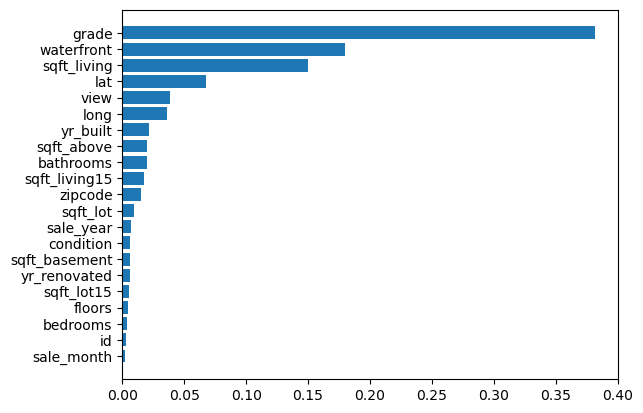

In [524]:
model1 = XGBRegressor()
model1.fit(X_train, y_train)

y_pred_1 = model1.predict(X_test)
y_pred_train_1 = model1.predict(X_train)

sort_idx = model1.feature_importances_.argsort()
plt.barh(X_test.columns[sort_idx],model1.feature_importances_[sort_idx])
plt.show()



In [525]:
new_row = evaluate_model("XGB 0", y_train, y_pred_train_1, y_test, y_pred_1)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
metrics_df 

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87


In [526]:
metrics_df

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87


In [527]:
test_predictions = pd.DataFrame({'ypred': y_pred_1, 'ytest': y_test, 'delta' : y_pred_1 - y_test}).sort_values('delta')
print(test_predictions[test_predictions["delta"] == test_predictions["delta"].max()])

          ypred     ytest      delta
4024 4168807.00 800000.00 3368807.00


In [528]:
model1.get_params(deep=True)

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

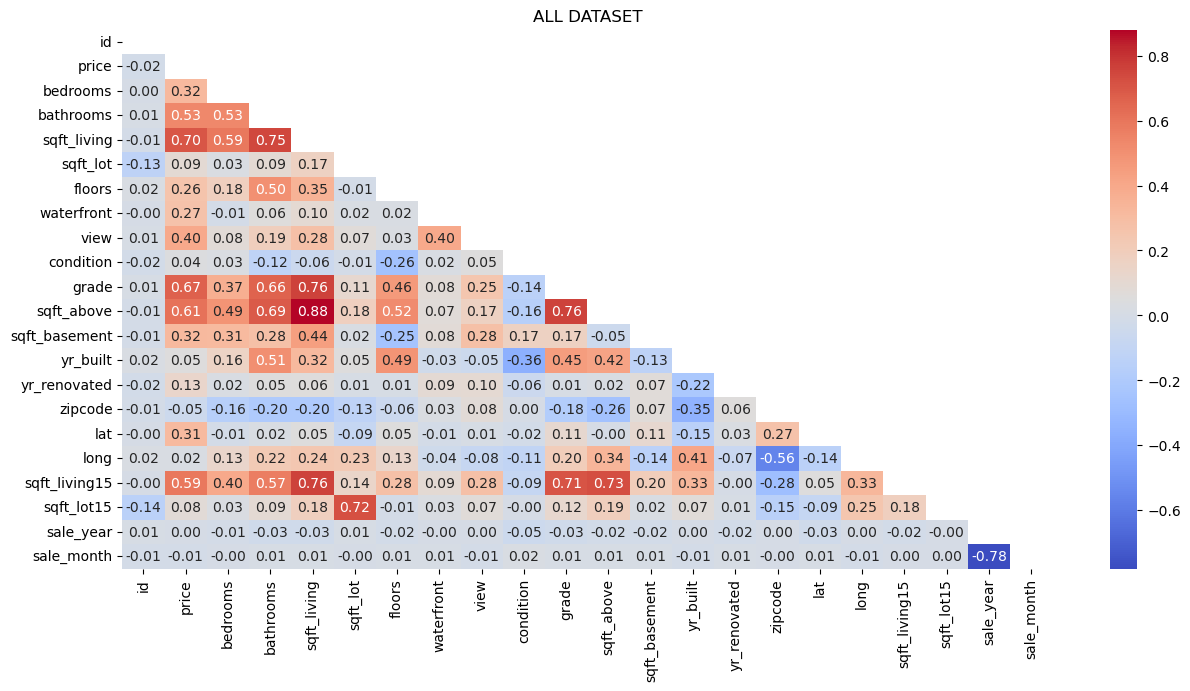

In [529]:
correlation_matrix = round(df[df.columns].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("ALL DATASET")
plt.show()

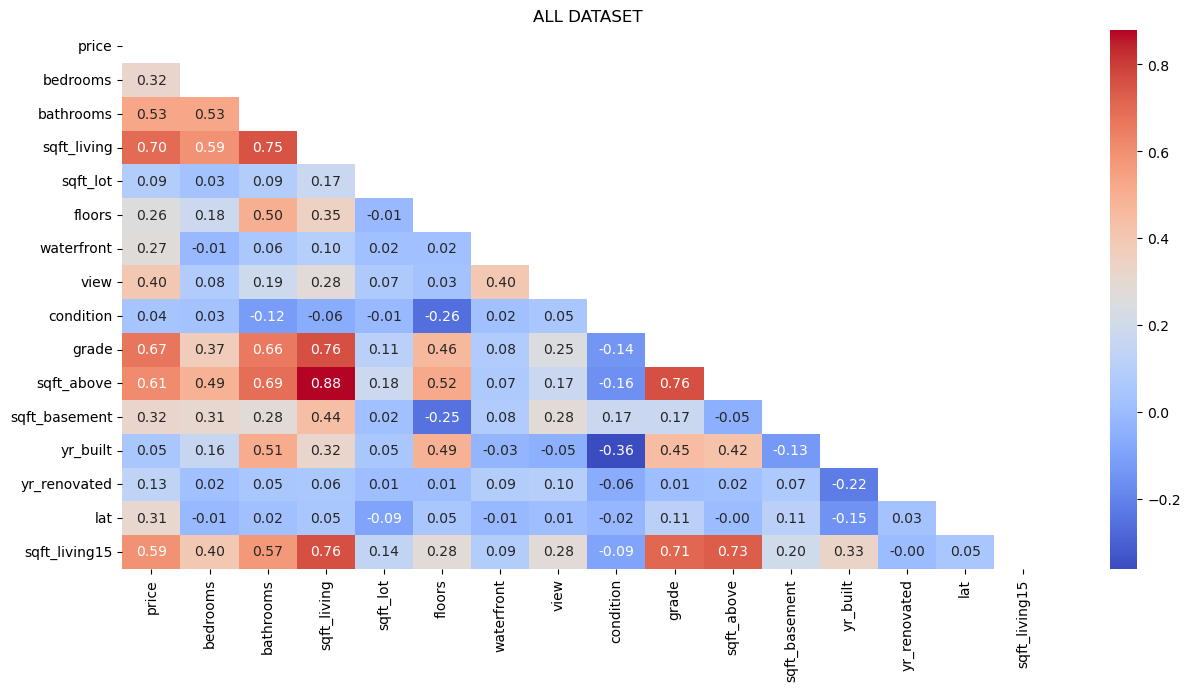

In [530]:
df2 = df.drop(['id', 'sale_month','sale_year','sqft_lot15','long','zipcode'], axis = 1)
correlation_matrix = round(df2[df2.columns].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("ALL DATASET")
plt.show()

X_train shape: (17289, 15)
X_test shape: (4323, 15)


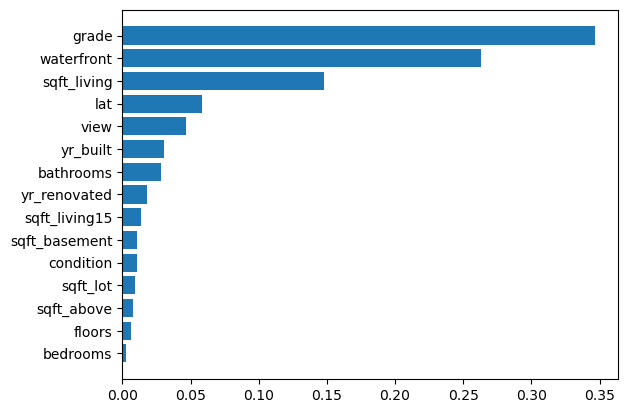

In [531]:
X2 = df2.drop('price', axis =1)
y2 = df2['price']
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

model1 = XGBRegressor()
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)
y_pred_train = model1.predict(X_train)

new_row = evaluate_model("Model after feature reduction", y_train, y_pred_train, y_test, y_pred)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

model1.feature_importances_
sort_idx = model1.feature_importances_.argsort()
plt.barh(X_test.columns[sort_idx],model1.feature_importances_[sort_idx])
plt.show()


In [532]:
metrics_df

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81


# APPLY log1p

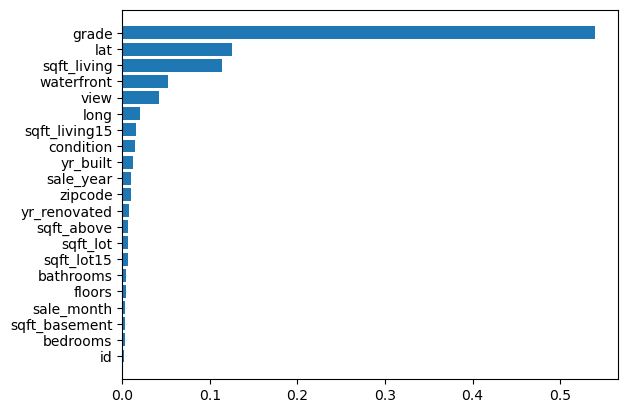

In [533]:
X_log = df.drop('price', axis =1)
y_log = df['price']

X_train_log, X_test_log, y_train, y_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=RANDOM_STATE
)

y_train_log = np.log1p(y_train)
#y_test_log= np.log1p(y_test)

model_log = XGBRegressor()
model_log.fit(X_train_log, y_train_log)

y_pred_log = model_log.predict(X_test_log)
y_pred_train_log = np.expm1(model_log.predict(X_train_log))

sort_idx = model_log.feature_importances_.argsort()
plt.barh(X_test_log.columns[sort_idx],model_log.feature_importances_[sort_idx])
plt.show()

In [534]:
new_row = evaluate_model("Model after log", y_train, y_pred_train_log, y_test, y_pred)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

In [535]:
metrics_df

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81


In [536]:
pd.DataFrame({'ypred': y_pred_log, 'ytest': y_test, 'delta' : y_pred_log - y_test}).sort_values('delta')

,ypred,ytest,delta
4411,15.55,5570000.00,-5569984.45
1448,15.25,5350000.00,-5349984.75
2626,14.99,4500000.00,-4499985.01
4149,15.07,4000000.00,-3999984.93
2085,15.21,3850000.00,-3849984.79
...,...,...,...
17579,12.17,90000.00,-89987.83
3108,11.69,89950.00,-89938.31
5866,11.97,89000.00,-88988.03
18467,11.97,83000.00,-82988.03


# TRY Hyperparameters

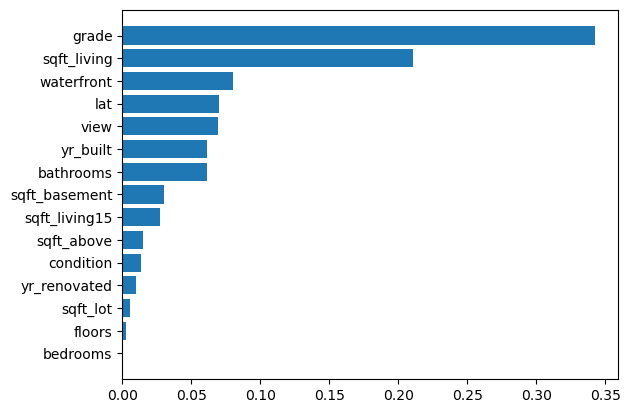

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model after Hyper,69917.72,170449.96,48882.00,83006.90,0.96,0.81


In [537]:
model_H = XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=50, 
    learning_rate=0.1, 
    max_depth=3)

model_H.fit(X_train, y_train)

y_pred = model1.predict(X_test)
y_pred_train = model1.predict(X_train)

sort_idx = model_H.feature_importances_.argsort()
plt.barh(X_test.columns[sort_idx],model_H.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model("Model after Hyper", y_train, y_pred_train, y_test, y_pred)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1}


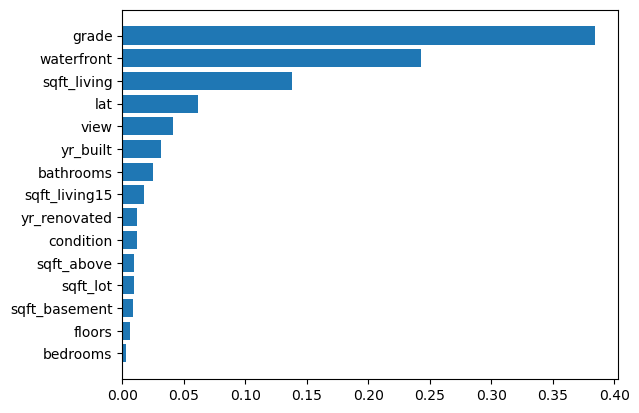

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model after Hyper,69917.72,170449.96,48882.00,83006.90,0.96,0.81
5,Model after Randomized Search,75236.74,157238.52,51581.83,79506.99,0.96,0.84


In [538]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor()

# Define parameter distribution for sampling
param_dist = {
    'n_estimators': [100, 300, 500, 800],
    'max_depth': list(range(3, 10)),
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'gamma': [0, 0.1, 0.3],
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,                 # number of random combinations to try
    cv=5,                      # 3-fold cross-validation (faster than 5)
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
    random_state=42
)

# Fit randomized search
#random_search.fit(X_train, y_train)
random_search.fit(
    X_train, y_train,
)
# Best parameters
print("Best parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

best_model.fit(
    X_train, y_train,
)
# Best model

# Evaluate on test set
y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

sort_idx = best_model.feature_importances_.argsort()
plt.barh(X_test.columns[sort_idx],best_model.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model("Model after Randomized Search", y_train, y_pred_train, y_test, y_pred)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

In [539]:
mae = mean_absolute_error(y_test, y_pred)
print("Test MAE:", mae)

Test MAE: 79506.98770927307


# L1

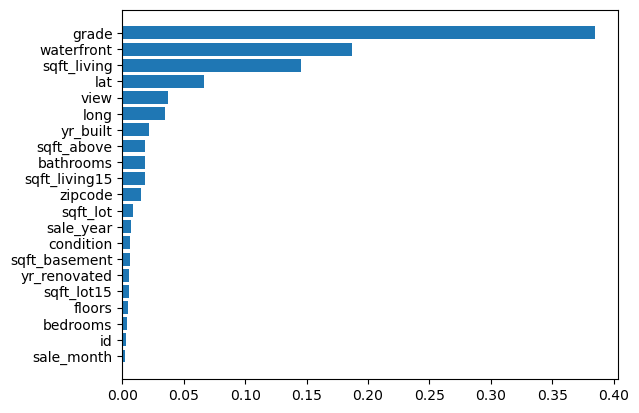

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model after Hyper,69917.72,170449.96,48882.00,83006.90,0.96,0.81
5,Model after Randomized Search,75236.74,157238.52,51581.83,79506.99,0.96,0.84
6,Model after L1 reg. with alpha 200,52762.73,133569.18,37958.69,67985.89,0.98,0.88


In [540]:
X_train_L1, X_test_L1, y_train_L1, y_test_L1 = X_train_0.copy(), X_test_0.copy(), y_train_0.copy(), y_test_0.copy()
alpha = 200
model_L1 = XGBRegressor(reg_alpha=alpha)
model_L1.fit(X_train_L1, y_train_L1)

y_pred_L1 = model_L1.predict(X_test_L1)
y_pred_train_L1 = model_L1.predict(X_train_L1)

sort_idx = model_L1.feature_importances_.argsort()
plt.barh(X_test_L1.columns[sort_idx],model_L1.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model(f"Model after L1 reg. with alpha {alpha}", y_train_L1, y_pred_train_L1, y_test_L1, y_pred_L1)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

# L2 Regularization

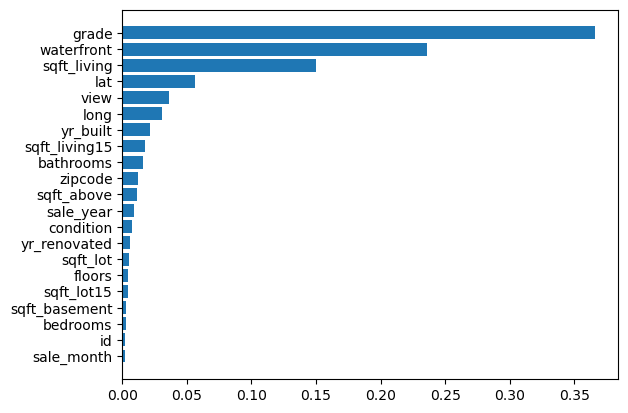

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Linear Regression,197659.54,211427.88,124881.99,126734.61,0.70,0.70
1,XGB 0,53442.07,138137.45,38170.54,68372.68,0.98,0.87
2,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
3,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
4,Model after Hyper,69917.72,170449.96,48882.00,83006.90,0.96,0.81
5,Model after Randomized Search,75236.74,157238.52,51581.83,79506.99,0.96,0.84
6,Model after L1 reg. with alpha 200,52762.73,133569.18,37958.69,67985.89,0.98,0.88
7,Model after L2 reg.,60533.45,130475.76,42367.74,68419.77,0.97,0.89


In [541]:
X_train_L2, X_test_L2, y_train_L2, y_test_L2 = X_train_0.copy(), X_test_0.copy(), y_train_0.copy(), y_test_0.copy()
lambda_l2 = 5
model_L2 = XGBRegressor(reg_lambda=lambda_l2, reg_alpha = alpha)
model_L2.fit(X_train_L2, y_train_L2)

y_pred_L2 = model_L2.predict(X_test_L2)
y_pred_train_L2 = model_L2.predict(X_train_L2)

sort_idx = model_L2.feature_importances_.argsort()
plt.barh(X_test_L2.columns[sort_idx],model_L2.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model("Model after L2 reg.", y_train_L2, y_pred_train_L2, y_test_L2, y_pred_L2)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

In [564]:
checks = X_test_L2.copy()
checks["y_pred"] = y_pred_L2
checks['y_real'] = y_test_L2
checks['delta'] = y_test_L2 - y_pred_L2
checks['relative_error'] = abs(checks.delta / checks.y_real)

In [600]:
check_11_grade = checks[checks['grade']==11].sort_values('relative_error',ascending=True)
len(check_11_grade[check_11_grade['relative_error'] < 0.01])
len(check_11_grade[check_11_grade['relative_error'] < 0.1])
len(check_11_grade[check_11_grade['relative_error'] < 0.2])


74

In [608]:
len(checks[checks['relative_error'] < 0.01]) / len(checks)
len(checks[checks['relative_error'] < 0.25]) / len(checks)

0.8806384455239417

In [581]:
len(checks[checks['relative_error']<0.0001])

2

In [584]:
checks[(checks['grade'] == 11) & (checks['relative_error'].abs() < 1e-6)].shape[0]

0

In [568]:
checks.grade.value_counts()

grade
7     1803
8     1173
9      526
6      422
10     223
11      97
5       58
12      17
13       3
4        1
Name: count, dtype: int64

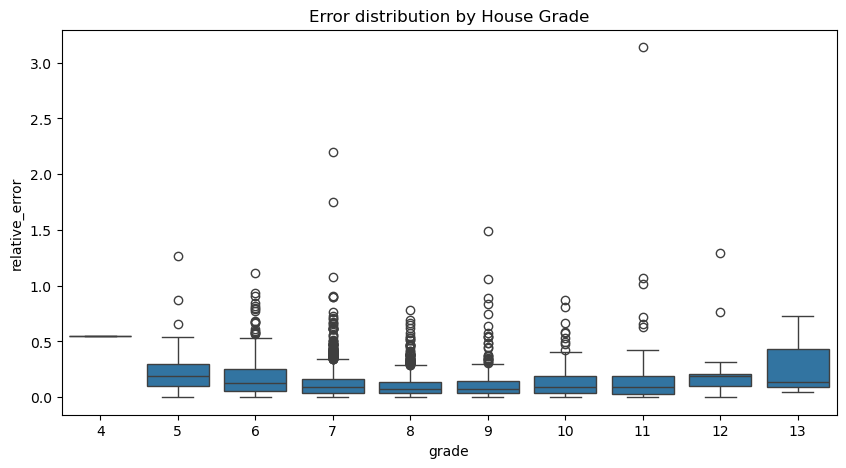

In [567]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=checks, x="grade", y="relative_error")

plt.title("Error distribution by House Grade")
plt.show()

In [543]:
checks = pd.concat([X_test_L2, y_pred_L2], axis=1)

TypeError: cannot concatenate object of type '<class 'numpy.ndarray'>'; only Series and DataFrame objs are valid

# OBJECTIVE AND EVAL_METRIC

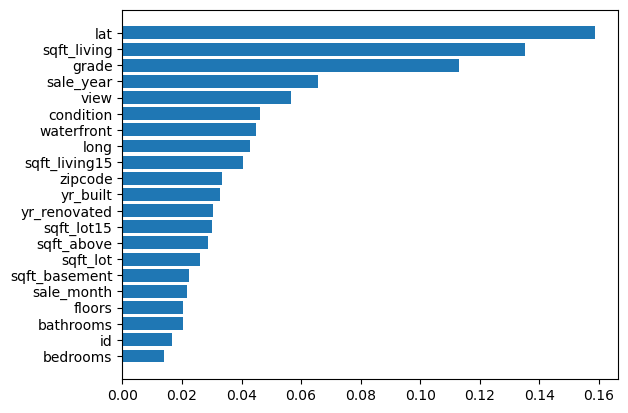

,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
0,Base model,53442.07,138137.45,38170.54,68372.68,0.98,0.87
1,Model after feature reduction,69917.72,170449.96,48882.00,83006.90,0.96,0.81
2,Model after log,60842.61,170449.96,39406.15,83006.90,0.97,0.81
3,Model after Hyper,69917.72,170449.96,48882.00,83006.90,0.96,0.81
4,Model after GridSearch,69917.72,170449.96,48882.00,83006.90,0.96,0.81
5,Model after L1 reg. with alpha 100,53345.52,137142.52,38305.38,68242.95,0.98,0.87
6,Model after L2 reg.,60374.03,130834.84,42177.36,68604.67,0.97,0.89
7,Model after L1 reg. with alpha 1000,54308.92,135277.63,38725.61,68197.35,0.98,0.88
8,Model after L1 reg. with alpha 10000,53564.75,139731.93,38339.48,68685.96,0.98,0.87
9,Model after L1 reg. with alpha 5000,53480.19,135598.89,38198.52,68186.97,0.98,0.88


In [ ]:
X_train_obj, X_test_obj, y_train_obj, y_test_obj = X_train_0.copy(), X_test_0.copy(), y_train_0.copy(), y_test_0.copy()
model_obj = XGBRegressor(objective='reg:absoluteerror', eval_metric='rmse')
model_obj.fit(X_train_obj, y_train_obj)

y_pred_obj = model_obj.predict(X_test_obj)
y_pred_train_obj = model_obj.predict(X_train_obj)

sort_idx = model_obj.feature_importances_.argsort()
plt.barh(X_test_obj.columns[sort_idx],model_obj.feature_importances_[sort_idx])
plt.show()

new_row = evaluate_model("Model after obj reg.", y_train_obj, y_pred_train_obj, y_test_obj, y_pred_obj)
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

metrics_df

In [447]:
df[df['yr_renovated']>0].min()

id              3600057.00
price            110000.00
bedrooms              1.00
bathrooms             0.75
sqft_living         520.00
sqft_lot           1024.00
floors                1.00
waterfront            0.00
view                  0.00
condition             1.00
grade                 4.00
sqft_above          520.00
sqft_basement         0.00
yr_built           1900.00
yr_renovated       1934.00
zipcode           98001.00
lat                  47.20
long               -122.51
sqft_living15       828.00
sqft_lot15         1281.00
sale_year          2014.00
sale_month            1.00
dtype: float64

# TRY REMOVE OUTLIERS

In [448]:
def identify_outliers_iqr(df, column, threshold=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for column in df2.columns:
    column_out, column_lower, column_upper = identify_outliers_iqr(df2, column)
    print(f'{column}: {len(column_out)}\nbounds: {column_lower:.2f} to {column_upper:.2f}\nminmax: {df2[column].min()} to {df2[column].max()}\n')

price: 1146
bounds: -162906.25 to 1129743.75
minmax: 75000.0 to 7700000.0

bedrooms: 545
bounds: 1.50 to 5.50
minmax: 0 to 11

bathrooms: 571
bounds: 0.62 to 3.62
minmax: 0.0 to 8.0

sqft_living: 572
bounds: -258.75 to 4235.25
minmax: 290 to 13540

sqft_lot: 2425
bounds: -3432.38 to 19160.62
minmax: 520 to 1651359

floors: 0
bounds: -0.50 to 3.50
minmax: 1.0 to 3.5

waterfront: 163
bounds: 0.00 to 0.00
minmax: 0 to 1

view: 2124
bounds: 0.00 to 0.00
minmax: 0 to 4

condition: 30
bounds: 1.50 to 5.50
minmax: 1 to 5

grade: 1911
bounds: 5.50 to 9.50
minmax: 1 to 13

sqft_above: 611
bounds: -340.00 to 3740.00
minmax: 290 to 9410

sqft_basement: 496
bounds: -840.00 to 1400.00
minmax: 0 to 4820

yr_built: 0
bounds: 1882.00 to 2066.00
minmax: 1900 to 2015

yr_renovated: 914
bounds: 0.00 to 0.00
minmax: 0 to 2015

lat: 2
bounds: 47.16 to 47.99
minmax: 47.1559 to 47.7776

sqft_living15: 544
bounds: 185.00 to 3665.00
minmax: 399 to 6210



In [449]:
# Define XGBRegressor model parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 3,
    'learning_rate': 0.1,
    'n_estimators': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': RANDOM_STATE
}

# Instantiate XGBRegressor with the parameters
model = XGBRegressor(**params)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 135603822868.30
R-squared: 0.10
